In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Display style
sns.set(style="whitegrid")

In [14]:
pd.set_option('display.max_colwidth', None)

## Load Dataset

In [15]:
folder_path = "/Users/harrychang/Desktop/GE5219/data/HistoricalRainfallacrossSingapore"

# find all csv files in folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# read and stack
df_list = [pd.read_csv(f) for f in csv_files]
df = pd.concat(df_list, ignore_index=True)

print(df.shape)

(33661499, 12)


## Data Preprocessing

In [16]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = pd.to_datetime(df['date'])

# Basic filters (optional but sane)
df = df[df['reading_type'].str.lower().str.contains("rain")]  # if mixed sensors

# Derived time features
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()
df['month'] = df['timestamp'].dt.to_period('M')
df['year'] = df['timestamp'].dt.year

df['is_morning_peak'] = df['hour'].between(7, 9) 
df['is_evening_peak'] = df['hour'].between(17, 20)
df['is_peak'] = df['is_morning_peak'] | df['is_evening_peak']

def classify_intensity(mmph):
    if mmph == 0:
        return "No rain"
    elif mmph <= 2.5:
        return "Light"
    elif mmph <= 10:
        return "Moderate"
    elif mmph <= 50:
        return "Heavy"
    else:
        return "Very heavy"

df['rain_intensity'] = df['reading_value'].apply(classify_intensity)

/var/folders/xx/lcjwqv657w52x118fhghnhj40000gn/T/ipykernel_4110/4122054418.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['timestamp'].dt.to_period('M')


In [17]:
df.head()

,date,timestamp,update_timestamp,station_id,station_name,station_device_id,location_longitude,location_latitude,reading_update_timestamp,reading_value,reading_type,reading_unit,hour,day_of_week,month,year,is_morning_peak,is_evening_peak,is_peak,rain_intensity
0,2020-01-01,2020-01-01 00:00:00+08:00,2020-01-05T17:47:38+08:00,S105,Admiralty Road West,S105,103.79525,1.45817,2020-01-05T17:47:38+08:00,0.0,TB1 Rainfall 5 Minute Total F,mm,0,Wednesday,2020-01,2020,False,False,False,No rain
1,2020-01-01,2020-01-01 00:00:00+08:00,2020-01-05T17:47:38+08:00,S77,Alexandra Road,S77,103.81250,1.29370,2020-01-05T17:47:38+08:00,0.0,TB1 Rainfall 5 Minute Total F,mm,0,Wednesday,2020-01,2020,False,False,False,No rain
2,2020-01-01,2020-01-01 00:00:00+08:00,2020-01-05T17:47:38+08:00,S109,Ang Mo Kio Avenue 5,S109,103.84920,1.37640,2020-01-05T17:47:38+08:00,0.0,TB1 Rainfall 5 Minute Total F,mm,0,Wednesday,2020-01,2020,False,False,False,No rain
3,2020-01-01,2020-01-01 00:00:00+08:00,2020-01-05T17:47:38+08:00,S117,Banyan Road,S117,103.67900,1.25600,2020-01-05T17:47:38+08:00,0.0,TB1 Rainfall 5 Minute Total F,mm,0,Wednesday,2020-01,2020,False,False,False,No rain
4,2020-01-01,2020-01-01 00:00:00+08:00,2020-01-05T17:47:38+08:00,S64,Bukit Panjang Road,S64,103.76030,1.38240,2020-01-05T17:47:38+08:00,0.0,TB1 Rainfall 5 Minute Total F,mm,0,Wednesday,2020-01,2020,False,False,False,No rain


In [19]:
df.columns

Index(['date', 'timestamp', 'update_timestamp', 'station_id', 'station_name',
       'station_device_id', 'location_longitude', 'location_latitude',
       'reading_update_timestamp', 'reading_value', 'reading_type',
       'reading_unit', 'hour', 'day_of_week', 'month', 'year',
       'is_morning_peak', 'is_evening_peak', 'is_peak', 'rain_intensity'],
      dtype='object')

## Data exploration

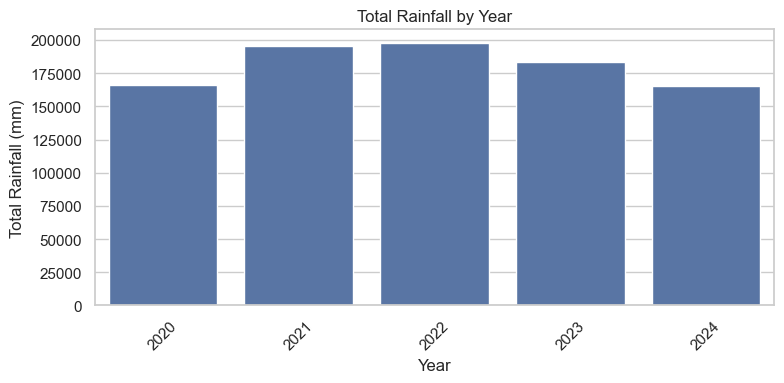

In [20]:
# total rainfal by year in sg (2020 to 2024)

yearly_rain = (
    df.groupby('year')['reading_value']
      .sum()
      .reset_index(name='total_rain_mm')
)

plt.figure(figsize=(8, 4))
sns.barplot(data=yearly_rain, x='year', y='total_rain_mm')
plt.title("Total Rainfall by Year")
plt.xlabel("Year")
plt.ylabel("Total Rainfall (mm)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# which month is wetter in singapore? using data from 2020 to 2024

df['month_name'] = df['timestamp'].dt.strftime('%b') 

monthly_rain = (
    df.groupby('month_name')['reading_value']
      .sum()
      .reset_index(name='total_rain_mm')
)

try:
    monthly_rain['month_order'] = pd.to_datetime(monthly_rain['month_name'].astype(str)).dt.month
    monthly_rain = monthly_rain.sort_values('month_order')
except:
    pass

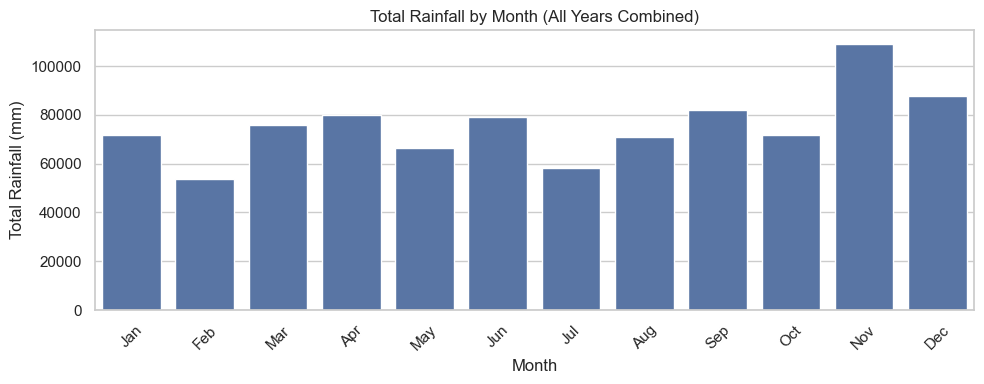

In [25]:
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

monthly_rain['month_name'] = pd.Categorical(
    monthly_rain['month_name'],
    categories=month_order,
    ordered=True
)

monthly_rain = monthly_rain.sort_values('month_name')

plt.figure(figsize=(10, 4))
sns.barplot(data=monthly_rain, x='month_name', y='total_rain_mm')
plt.title("Total Rainfall by Month (All Years Combined)")
plt.xlabel("Month")
plt.ylabel("Total Rainfall (mm)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/xx/lcjwqv657w52x118fhghnhj40000gn/T/ipykernel_4110/4205150671.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['timestamp'].dt.to_period('M').astype(str)


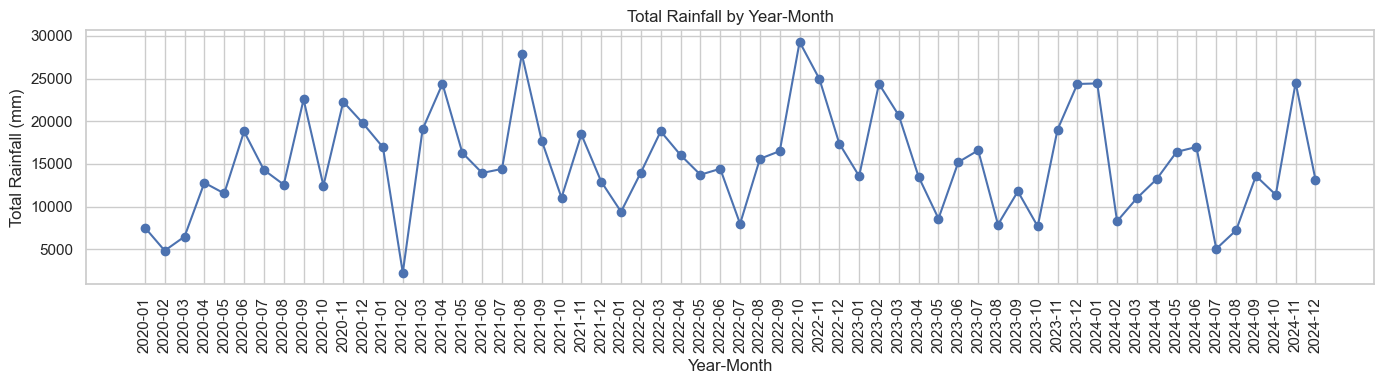

In [27]:
# Create proper year-month label
df['year_month'] = df['timestamp'].dt.to_period('M').astype(str)

ym_rain = (
    df.groupby('year_month')['reading_value']
      .sum()
      .reset_index(name='total_rain_mm')
)

plt.figure(figsize=(14, 4))
plt.plot(ym_rain['year_month'], ym_rain['total_rain_mm'], marker='o')
plt.title("Total Rainfall by Year-Month")
plt.xlabel("Year-Month")
plt.ylabel("Total Rainfall (mm)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

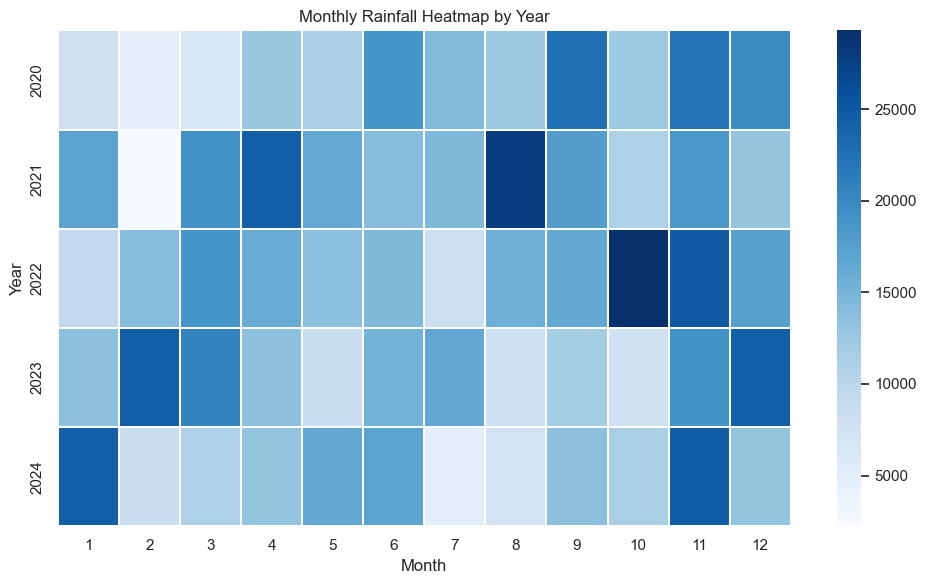

In [28]:
heat = (
    df.groupby(['year', df['timestamp'].dt.month])['reading_value']
      .sum()
      .reset_index(name='total_rain_mm')
      .pivot(index='year', columns='timestamp', values='total_rain_mm')
)

plt.figure(figsize=(10, 6))
sns.heatmap(heat, cmap="Blues", linewidths=0.3)
plt.title("Monthly Rainfall Heatmap by Year")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

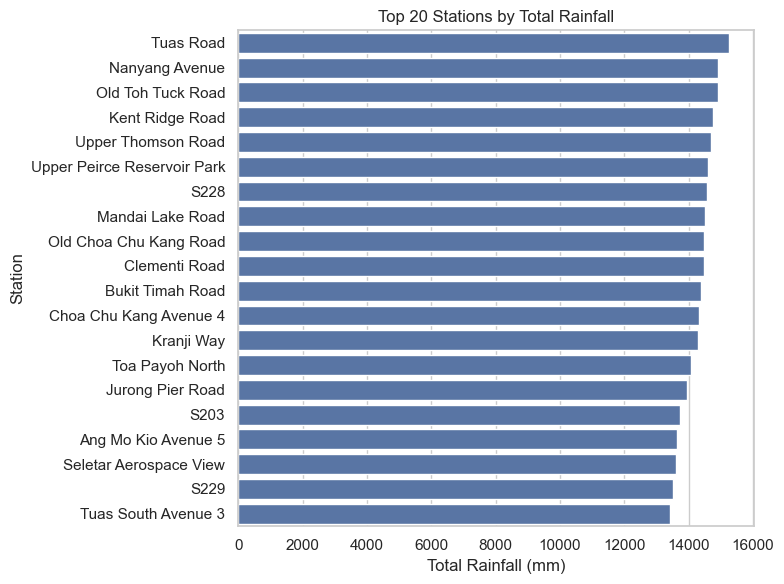

In [29]:
station_rain = (
    df.groupby(['station_id', 'station_name'])['reading_value']
      .sum()
      .reset_index(name='total_rain_mm')
      .sort_values('total_rain_mm', ascending=False)
)

# Top 20 stations
top_n = 20
top_station_rain = station_rain.head(top_n)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=top_station_rain,
    y='station_name',
    x='total_rain_mm',
    orient='h'
)
plt.title(f"Top {top_n} Stations by Total Rainfall")
plt.xlabel("Total Rainfall (mm)")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

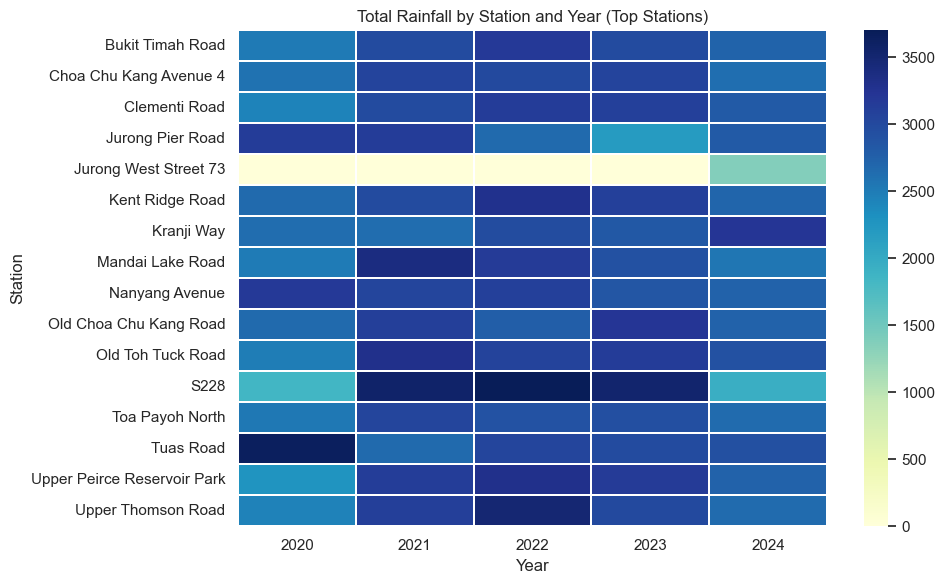

In [30]:
station_year = (
    df.groupby(['station_id', 'station_name', 'year'])['reading_value']
      .sum()
      .reset_index(name='total_rain_mm')
)

# Example: heatmap for a subset of key stations
key_stations = (
    station_rain.head(15)['station_id']
    .tolist()
)

subset = station_year[station_year['station_id'].isin(key_stations)]
pivot_sy = subset.pivot_table(
    index='station_name',
    columns='year',
    values='total_rain_mm',
    fill_value=0
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_sy, cmap="YlGnBu", linewidths=0.3)
plt.title("Total Rainfall by Station and Year (Top Stations)")
plt.xlabel("Year")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

## Further Exploration

In [31]:
# Heavy rain definition
df['is_heavy'] = df['rain_intensity'].isin(['Heavy', 'Very heavy'])
df['is_rain'] = df['rain_intensity'] != 'No rain'

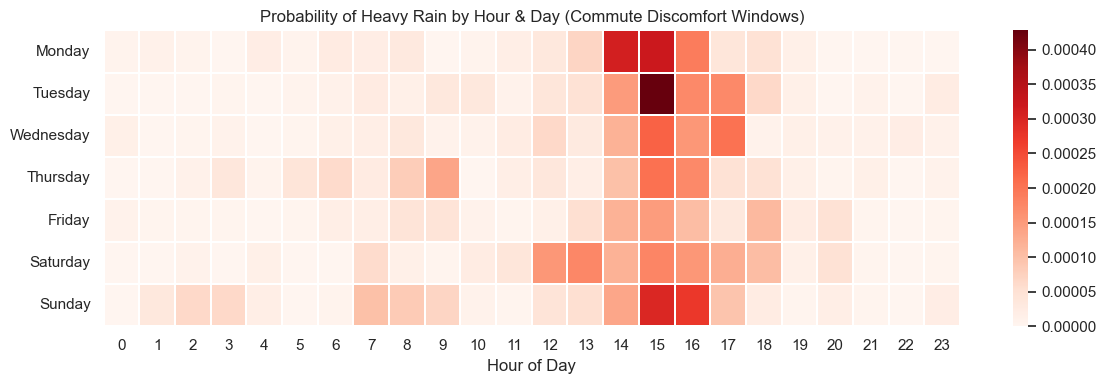

In [37]:
# Probability of heavy rain at each (day_of_week, hour)
pivot_hd = (
    df.groupby(['day_of_week', 'hour'])['is_heavy']
      .mean()
      .reset_index(name='heavy_prob')
)

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
pivot_hd['day_of_week'] = pd.Categorical(pivot_hd['day_of_week'], categories=day_order, ordered=True)

heat_hd = pivot_hd.pivot(index='day_of_week', columns='hour', values='heavy_prob')

plt.figure(figsize=(12, 4))
sns.heatmap(heat_hd, cmap="Reds", vmin=0, vmax=heat_hd.to_numpy().max(), linewidths=0.3)
plt.title("Probability of Heavy Rain by Hour & Day (Commute Discomfort Windows)")
plt.xlabel("Hour of Day")
plt.ylabel("")
plt.tight_layout()
plt.show()

/var/folders/xx/lcjwqv657w52x118fhghnhj40000gn/T/ipykernel_4110/1940843173.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  peak['year_month'] = peak['timestamp'].dt.to_period('M').astype(str)
/var/folders/xx/lcjwqv657w52x118fhghnhj40000gn/T/ipykernel_4110/1940843173.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peak['year_month'] = peak['timestamp'].dt.to_period('M').astype(str)


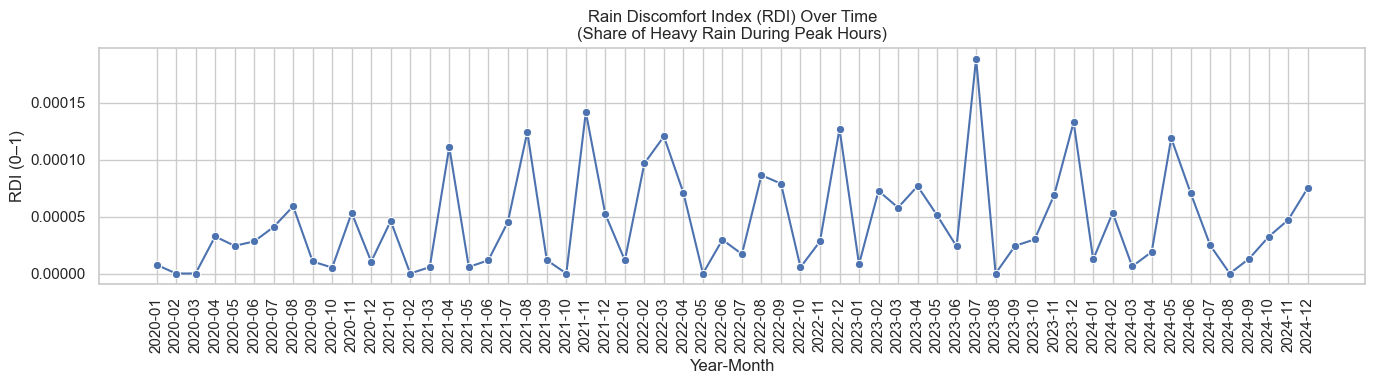

In [38]:
# Peak-only subset
peak = df[df['is_peak']]

# Year-month for grouping
peak['year_month'] = peak['timestamp'].dt.to_period('M').astype(str)

rdi_month = (
    peak.groupby('year_month')['is_heavy']
        .mean()
        .reset_index(name='rdi')
)

plt.figure(figsize=(14, 4))
sns.lineplot(data=rdi_month, x='year_month', y='rdi', marker='o')
plt.title("Rain Discomfort Index (RDI) Over Time\n(Share of Heavy Rain During Peak Hours)")
plt.xlabel("Year-Month")
plt.ylabel("RDI (0–1)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

/var/folders/xx/lcjwqv657w52x118fhghnhj40000gn/T/ipykernel_4110/3043082710.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peak['month_num'] = peak['timestamp'].dt.month


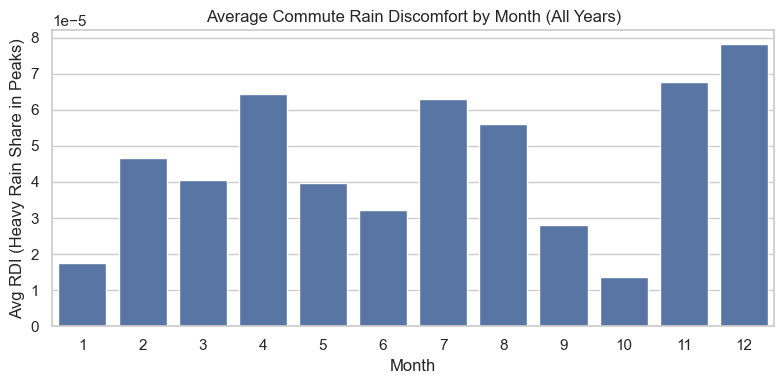

In [39]:
peak['month_num'] = peak['timestamp'].dt.month
monthly_rdi = (
    peak.groupby('month_num')['is_heavy']
        .mean()
        .reset_index(name='rdi')
)

plt.figure(figsize=(8,4))
sns.barplot(data=monthly_rdi, x='month_num', y='rdi')
plt.title("Average Commute Rain Discomfort by Month (All Years)")
plt.xlabel("Month")
plt.ylabel("Avg RDI (Heavy Rain Share in Peaks)")
plt.tight_layout()
plt.show()

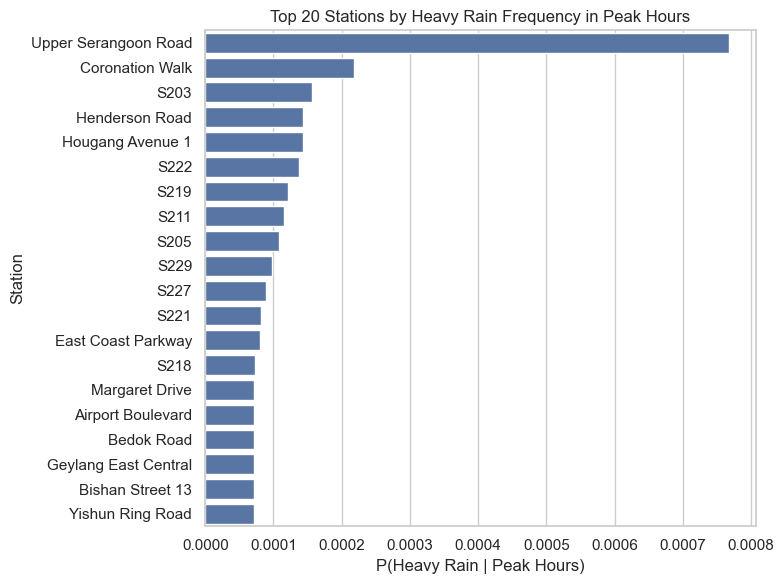

In [40]:
station_peak = (
    peak.groupby(['station_id', 'station_name'])
        .agg(
            peak_heavy_freq=('is_heavy', 'mean'),     # P(heavy | peak)
            peak_rain_freq=('is_rain', 'mean')        # P(any rain | peak)
        )
        .reset_index()
)

# Top stations by peak heavy rain frequency
top_station_peak = station_peak.sort_values('peak_heavy_freq', ascending=False).head(20)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=top_station_peak,
    y='station_name',
    x='peak_heavy_freq',
    orient='h'
)
plt.title("Top 20 Stations by Heavy Rain Frequency in Peak Hours")
plt.xlabel("P(Heavy Rain | Peak Hours)")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

In [41]:
import folium
import numpy as np
import branca.colormap as cm

# Merge lat/lon in if not already
station_geo = (
    df.groupby(['station_id', 'station_name'])
      .agg(
          lat=('location_latitude', 'first'),
          lon=('location_longitude', 'first')
      )
      .reset_index()
)

station_peak_geo = station_peak.merge(station_geo, on=['station_id','station_name'], how='left')

m = folium.Map(location=[1.3521, 103.8198], zoom_start=11, tiles="CartoDB positron")

vmin = station_peak_geo['peak_heavy_freq'].min()
vmax = station_peak_geo['peak_heavy_freq'].max()
colormap = cm.linear.YlOrRd_09.scale(vmin, vmax)
colormap.caption = "P(Heavy Rain | Peak Hours)"
colormap.add_to(m)

for _, row in station_peak_geo.iterrows():
    freq = row['peak_heavy_freq']
    if np.isnan(freq):
        continue

    color = colormap(freq)

    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=4 + 12 * freq,  # bigger + redder = worse
        popup=(
            f"<b>{row['station_name']}</b><br>"
            f"P(Heavy rain | peak): {freq:.1%}<br>"
            f"P(Any rain | peak): {row['peak_rain_freq']:.1%}"
        ),
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.85,
    ).add_to(m)

m

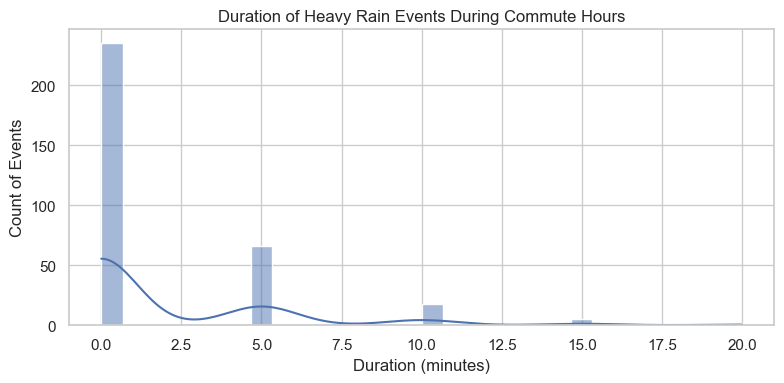

In [42]:
df_sorted = df.sort_values(['station_id', 'timestamp'])

# heavy in peaks only
df_sorted['is_heavy_peak'] = df_sorted['is_heavy'] & df_sorted['is_peak']

# Event id: start when current is heavy_peak and previous is not
df_sorted['event_id'] = (
    (df_sorted['is_heavy_peak'] & ~df_sorted['is_heavy_peak'].shift(fill_value=False))
    .cumsum()
)
df_sorted.loc[~df_sorted['is_heavy_peak'], 'event_id'] = np.nan

events = (
    df_sorted.dropna(subset=['event_id'])
             .groupby('event_id')
             .agg(
                 station_name=('station_name', 'first'),
                 start=('timestamp', 'min'),
                 end=('timestamp', 'max')
             )
             .reset_index(drop=True)
)

events['duration_min'] = (events['end'] - events['start']).dt.total_seconds() / 60

plt.figure(figsize=(8,4))
sns.histplot(events['duration_min'], bins=30, kde=True)
plt.title("Duration of Heavy Rain Events During Commute Hours")
plt.xlabel("Duration (minutes)")
plt.ylabel("Count of Events")
plt.tight_layout()
plt.show()

## Advanced Visualizations

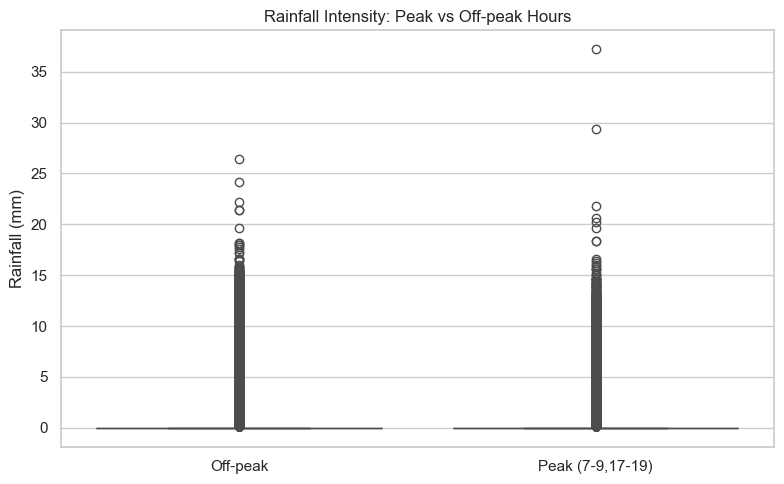

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df.assign(peak_label=np.where(df['is_peak'], 'Peak (7-9,17-19)', 'Off-peak')),
    x='peak_label',
    y='reading_value'
)
plt.title("Rainfall Intensity: Peak vs Off-peak Hours")
plt.xlabel("")
plt.ylabel("Rainfall (mm)")
plt.tight_layout()
plt.show()

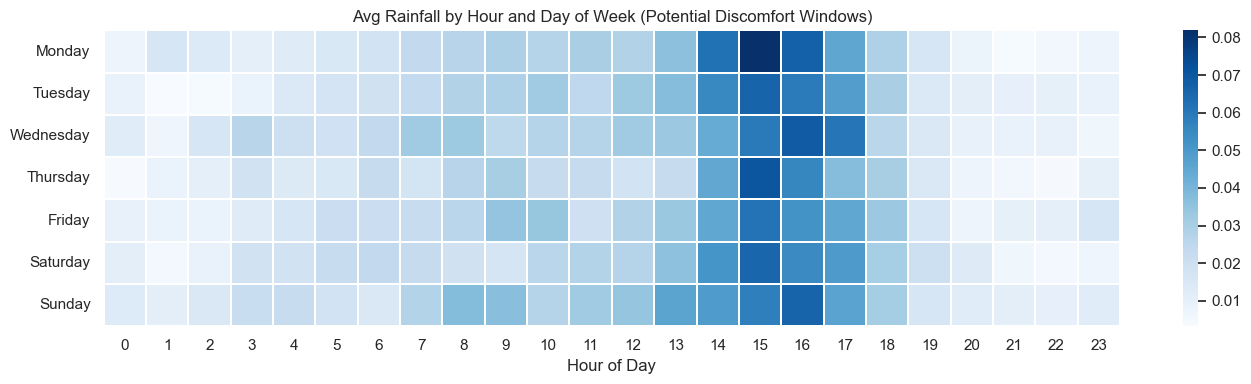

In [7]:
pivot = (
    df.groupby(['day_of_week', 'hour'])['reading_value']
      .mean()
      .reset_index()
)

# Order days
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
pivot['day_of_week'] = pd.Categorical(pivot['day_of_week'], categories=day_order, ordered=True)
pivot = pivot.pivot(index='day_of_week', columns='hour', values='reading_value')

plt.figure(figsize=(14, 4))
sns.heatmap(pivot, cmap="Blues", linewidths=0.3)
plt.title("Avg Rainfall by Hour and Day of Week (Potential Discomfort Windows)")
plt.xlabel("Hour of Day")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [8]:
station_stats = (
    df.groupby(['station_id', 'station_name', 'location_latitude', 'location_longitude'])
    .agg(
        mean_rain=('reading_value','mean'),
        heavy_rain_freq=('reading_value', lambda x: (x >= 10).mean()),
        peak_heavy_freq=('reading_value', 
                         lambda x: ((x >= 10) & 
                                    (df.loc[x.index, 'is_peak'])).mean())
    )
    .reset_index()
)

In [9]:
import folium
from folium.plugins import HeatMap

# Center on Singapore
m = folium.Map(location=[1.3521, 103.8198], zoom_start=11, tiles="CartoDB positron")

for _, row in station_stats.iterrows():
    # scale radius / color by peak_heavy_freq
    freq = row['peak_heavy_freq']
    if np.isnan(freq):
        continue

    folium.CircleMarker(
        location=[row['location_latitude'], row['location_longitude']],
        radius=3 + 20 * freq,  # larger if more often heavy rain at peak
        popup=(
            f"{row['station_name']}<br>"
            f"Peak heavy rain freq: {freq:.2%}<br>"
            f"Overall mean rain: {row['mean_rain']:.2f} mm"
        ),
        color=None,
        fill=True,
        fill_opacity=0.7,
    ).add_to(m)

m  # in notebook, this will render

In [10]:
import folium
from folium.plugins import HeatMap
import branca.colormap as cm

m = folium.Map(location=[1.3521, 103.8198], zoom_start=11, tiles="CartoDB positron")

# Build a colormap based on peak_heavy_freq
vmin = station_stats['peak_heavy_freq'].min()
vmax = station_stats['peak_heavy_freq'].max()

colormap = cm.linear.YlOrRd_09.scale(vmin, vmax)  # Yellow -> Red
colormap.caption = "Peak Heavy Rain Frequency"
colormap.add_to(m)

for _, row in station_stats.iterrows():
    freq = row['peak_heavy_freq']
    if np.isnan(freq):
        continue

    color = colormap(freq)  # get hex color from freq

    folium.CircleMarker(
        location=[row['location_latitude'], row['location_longitude']],
        radius=3 + 20 * freq,
        popup=(
            f"<b>{row['station_name']}</b><br>"
            f"Peak heavy rain freq: {freq:.2%}<br>"
            f"Overall mean rain: {row['mean_rain']:.2f} mm"
        ),
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
    ).add_to(m)

m


In [11]:
heat_data = [
    [row['location_latitude'], row['location_longitude'], row['peak_heavy_freq']]
    for _, row in station_stats.iterrows()
    if not np.isnan(row['peak_heavy_freq'])
]

m2 = folium.Map(location=[1.3521, 103.8198], zoom_start=11, tiles="CartoDB positron")
HeatMap(heat_data, max_zoom=13, radius=18, blur=16).add_to(m2)
m2

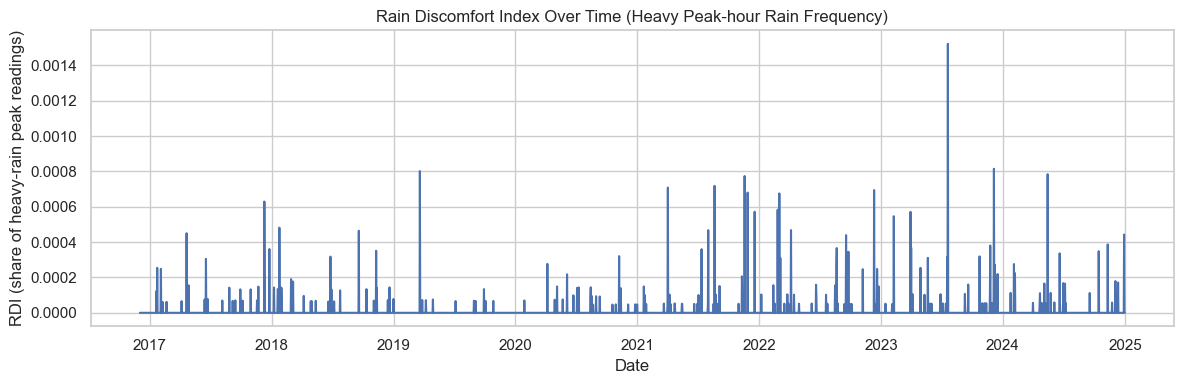

In [12]:
heavy_thresh = 10

df['is_heavy_peak'] = (df['reading_value'] >= heavy_thresh) & (df['is_peak'])

daily_rdi = (
    df.groupby(df['timestamp'].dt.date)['is_heavy_peak']
      .mean()  # or sum, depending on sampling frequency
      .rename("rdi")
      .reset_index()
)

plt.figure(figsize=(12,4))
plt.plot(daily_rdi['timestamp'], daily_rdi['rdi'])
plt.title("Rain Discomfort Index Over Time (Heavy Peak-hour Rain Frequency)")
plt.xlabel("Date")
plt.ylabel("RDI (share of heavy-rain peak readings)")
plt.tight_layout()
plt.show()